# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Hilwa Hilyatun Niswah]
- **Email:** [hilwahilyatun06@gmail.com]
- **ID Dicoding:** [hilwahilyatunniswah]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perkembangan jumlah pesanan dan total nilai penjualan setiap bulan selama periode September 2016 hingga September 2018?
- **Pertanyaan 2:** Kategori produk apa yang memiliki jumlah pesanan dan total nilai penjualan tertinggi selama periode September 2016 hingga Oktober 2018?


## Import Semua Packages/Library yang Digunakan

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

## Data Wrangling

In [29]:
zip_path = '/content/E-commerce-public-dataset.zip'
extract_path = '/content/ecommerce'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

### Gathering Data

In [30]:
os.listdir('/content/ecommerce/E-Commerce Public Dataset')

['order_reviews_dataset.csv',
 'New Text Document.txt',
 'order_payments_dataset.csv',
 'sellers_dataset.csv',
 'order_items_dataset.csv',
 'orders_dataset.csv',
 'customers_dataset.csv',
 'geolocation_dataset.csv',
 'product_category_name_translation.csv',
 'products_dataset.csv']

#### Load Dataset ...

In [31]:
orders_df = pd.read_csv('/content/ecommerce/E-Commerce Public Dataset/orders_dataset.csv')
order_items_df = pd.read_csv('/content/ecommerce/E-Commerce Public Dataset/order_items_dataset.csv')
products_df = pd.read_csv('/content/ecommerce/E-Commerce Public Dataset/products_dataset.csv')
customers_df = pd.read_csv('/content/ecommerce/E-Commerce Public Dataset/customers_dataset.csv')
category_translation_df = pd.read_csv('/content/ecommerce/E-Commerce Public Dataset/product_category_name_translation.csv')

print("Orders:", orders_df.shape)
print("Order Items:", order_items_df.shape)
print("Products:", products_df.shape)
print("Customers:", customers_df.shape)
print("Category Translation:", category_translation_df.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Category Translation: (71, 2)


**Insight:** (Opsional)


*   Dataset terdiri dari lima tabel utama, yaitu Orders, Order Items, Products, Customers, dan Category Translation.

*   Tabel Order Items memiliki jumlah data paling banyak, yaitu 112.650 baris, sedangkan Category Translation memiliki jumlah data paling sedikit, yaitu 71 baris.

*   Tabel Orders dan Customers memiliki jumlah baris yang sama, yaitu 99.441 baris, sehingga terdapat kemungkinan adanya hubungan antara data pesanan dan pelanggan
*   Kelima dataset memiliki struktur dan jumlah kolom yang berbeda sesuai dengan informasi yang disimpan pada masing-masing tabel.











### Assessing Data

#### Identifying ... problem

In [32]:
zip_path = '/content/E-commerce-public-dataset.zip'
extract_path = '/content/ecommerce'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['E-Commerce Public Dataset']

**Steps to Take:**
- Melakukan pengecekan terhadap missing value pada setiap dataset, terutama pada kolom tanggal di orders_df dan atribut produk di products_df.
- Mengidentifikasi kolom tanggal yang masih bertipe object dan mengubahnya menjadi tipe datetime agar dapat digunakan untuk analisis berdasarkan waktu.

**Insight:** (Opsional)
- Ditemukan missing value pada beberapa kolom di dataset Orders dan Products, sedangkan dataset Order Items, Customers, dan Category Translation tidak memiliki missing value.
- Kolom tanggal pada dataset Orders dan shipping_limit_date pada Order Items masih bertipe object, sehingga perlu dikonversi ke tipe datetime sebelum dilakukan analisis lebih lanjut.

### Cleaning Data

#### Fixing ... problem

In [33]:
# Mengubah kolom tanggal pada Orders menjadi datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

# Mengubah kolom tanggal pada Order Items menjadi datetime
order_items_df['shipping_limit_date'] = pd.to_datetime(
    order_items_df['shipping_limit_date'],
    errors='coerce'
)

# Menangani missing value pada kategori produk
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')

# Menangani missing value pada kolom numerik produk
numeric_columns = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in numeric_columns:
    products_df[col] = products_df[col].fillna(products_df[col].median())

print("Cleaning data selesai.")

Cleaning data selesai.


**Insight:** (Opsional)
- Kolom tanggal pada dataset Orders dan Order Items dikonversi menjadi tipe datetime agar dapat digunakan untuk analisis berdasarkan waktu.
- Missing value pada kategori produk diisi dengan unknown, sedangkan missing value pada atribut numerik produk diisi menggunakan nilai median sehingga data tetap dapat digunakan dalam proses analisis.

## Exploratory Data Analysis (EDA)

### Explore Data Berdasarkan Pertanyaan Bisnis

In [34]:
# Menggabungkan data Orders dan Order Items
sales_df = pd.merge(
    orders_df[['order_id', 'order_purchase_timestamp']],
    order_items_df[['order_id', 'price']],
    on='order_id',
    how='inner'
)

# Membuat kolom bulan
sales_df['month'] = sales_df['order_purchase_timestamp'].dt.to_period('M')

# Menghitung jumlah pesanan dan total nilai penjualan setiap bulan
monthly_sales = sales_df.groupby('month').agg(
    total_orders=('order_id', 'nunique'),
    total_sales=('price', 'sum')
).reset_index()

print("=== Perkembangan Pesanan dan Penjualan per Bulan ===")
display(monthly_sales)


# Menggabungkan Order Items dengan Products
category_sales = pd.merge(
    order_items_df[['order_id', 'product_id', 'price']],
    products_df[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Menggabungkan dengan Category Translation
category_sales = pd.merge(
    category_sales,
    category_translation_df,
    on='product_category_name',
    how='left'
)

# Menggunakan nama kategori bahasa Inggris
category_sales['category'] = category_sales[
    'product_category_name_english'
].fillna('unknown')

# Menghitung jumlah pesanan dan total penjualan berdasarkan kategori
category_summary = category_sales.groupby('category').agg(
    total_orders=('order_id', 'nunique'),
    total_sales=('price', 'sum')
).reset_index()

# Mengurutkan berdasarkan total penjualan tertinggi
category_summary = category_summary.sort_values(
    by='total_sales',
    ascending=False
)

print("\n=== 10 Kategori dengan Pesanan dan Penjualan Tertinggi ===")
display(category_summary.head(10))

=== Perkembangan Pesanan dan Penjualan per Bulan ===


,month,total_orders,total_sales
0,2016-09,3,267.36
1,2016-10,308,49507.66
2,2016-12,1,10.90
3,2017-01,789,120312.87
4,2017-02,1733,247303.02
5,2017-03,2641,374344.30
6,2017-04,2391,359927.23
7,2017-05,3660,506071.14
8,2017-06,3217,433038.60
9,2017-07,3969,498031.48



=== 10 Kategori dengan Pesanan dan Penjualan Tertinggi ===


,category,total_orders,total_sales
43,health_beauty,8836,1258681.34
71,watches_gifts,5624,1205005.68
7,bed_bath_table,9417,1036988.68
65,sports_leisure,7720,988048.97
15,computers_accessories,6689,911954.32
39,furniture_decor,6449,729762.49
20,cool_stuff,3632,635290.85
49,housewares,5884,632248.66
5,auto,3897,592720.11
42,garden_tools,3518,485256.46


**Insight:** (Opsional)
- Analisis eksploratif menunjukkan adanya perubahan jumlah pesanan dan total nilai penjualan dari bulan ke bulan selama periode pengamatan.
- Beberapa kategori produk memiliki jumlah pesanan dan nilai penjualan yang lebih tinggi dibandingkan kategori lainnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

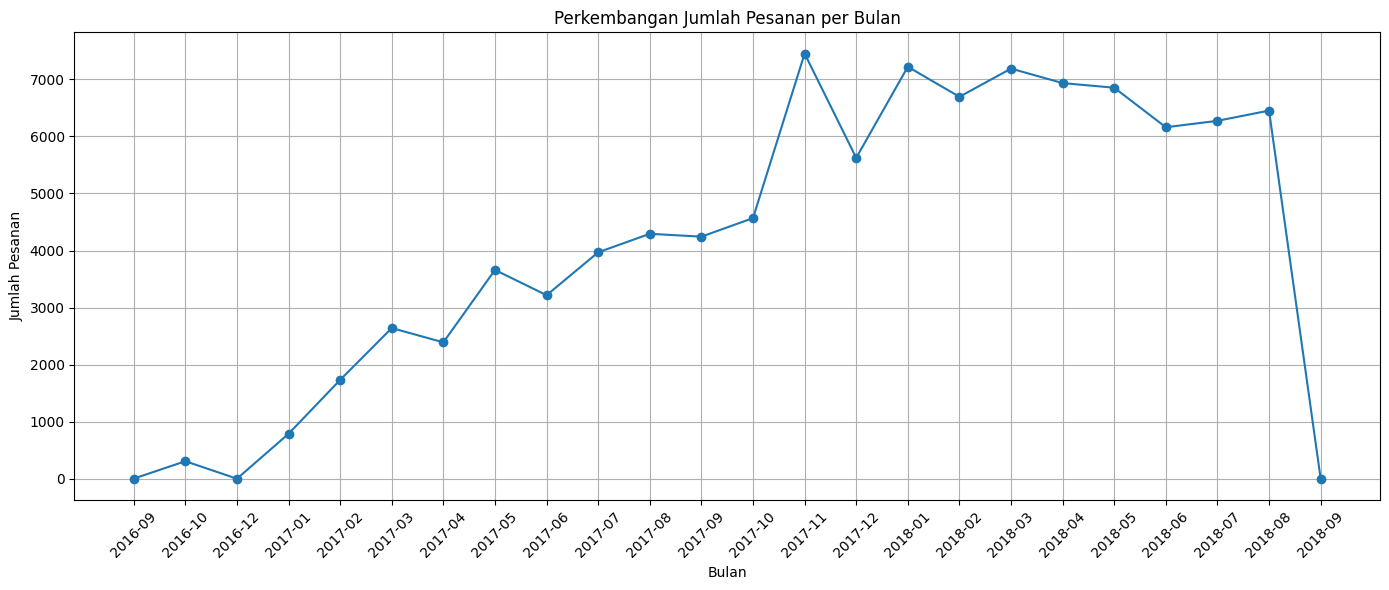

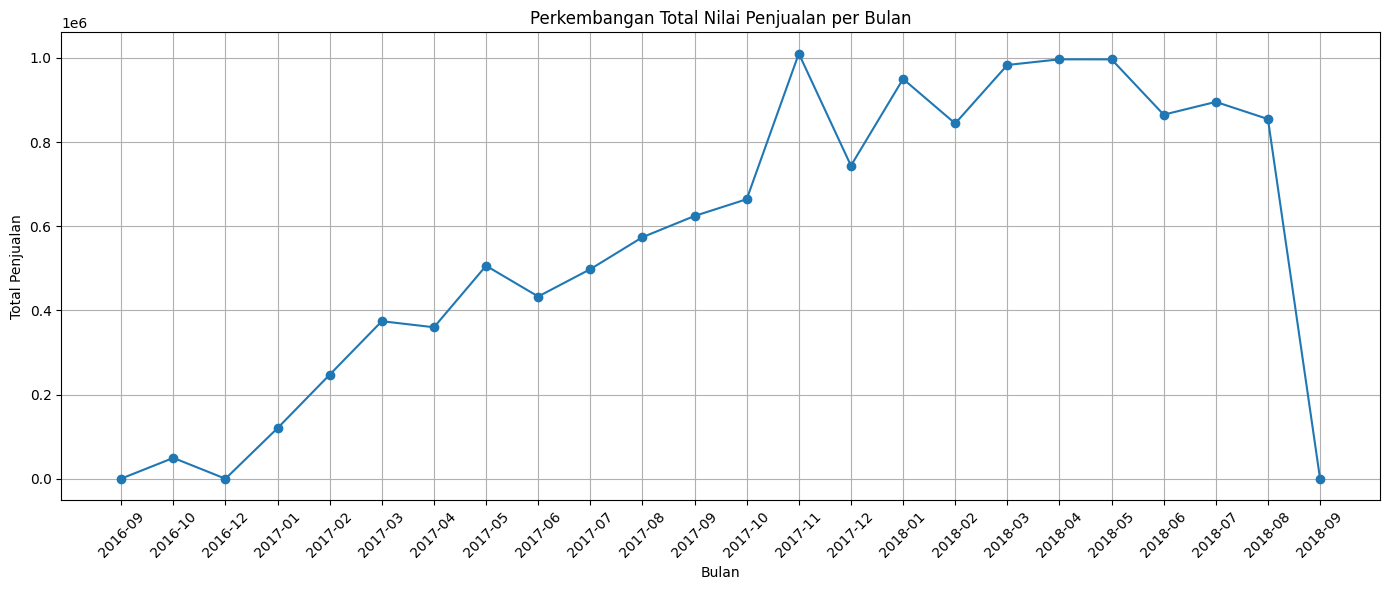

In [35]:
# Membuat grafik perkembangan jumlah pesanan per bulan
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['month'].astype(str),
    monthly_sales['total_orders'],
    marker='o'
)

plt.title('Perkembangan Jumlah Pesanan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# Membuat grafik perkembangan total nilai penjualan per bulan
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['month'].astype(str),
    monthly_sales['total_sales'],
    marker='o'
)

plt.title('Perkembangan Total Nilai Penjualan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Pertanyaan 2:

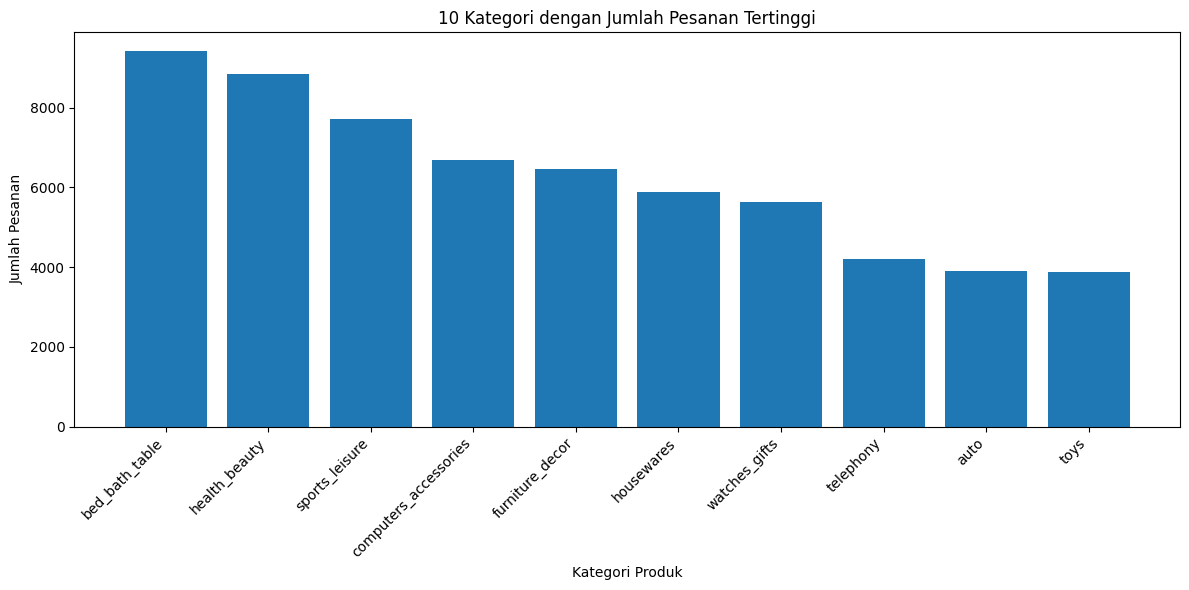

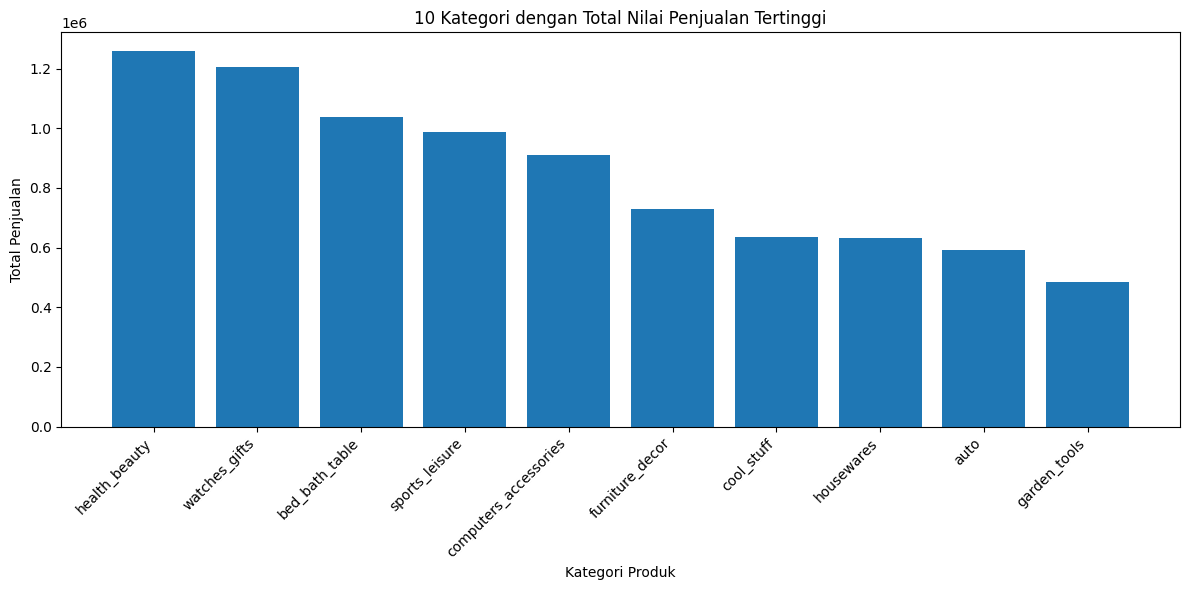

In [36]:
# Mengambil 10 kategori berdasarkan jumlah pesanan
top_orders = category_summary.sort_values(
    by='total_orders',
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_orders['category'],
    top_orders['total_orders']
)

plt.title('10 Kategori dengan Jumlah Pesanan Tertinggi')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Mengambil 10 kategori berdasarkan total penjualan
top_sales = category_summary.sort_values(
    by='total_sales',
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_sales['category'],
    top_sales['total_sales']
)

plt.title('10 Kategori dengan Total Nilai Penjualan Tertinggi')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Jumlah pesanan dan total nilai penjualan secara umum mengalami peningkatan dari awal periode hingga mencapai puncaknya pada November 2017, kemudian mengalami fluktuasi pada periode berikutnya.
- Kategori bed_bath_table memiliki jumlah pesanan tertinggi, sedangkan health_beauty memiliki total nilai penjualan tertinggi. Hal ini menunjukkan bahwa jumlah pesanan dan nilai penjualan dapat memiliki pola yang berbeda.

## Analisis Lanjutan (Opsional)

**Insight:** (Opsional)
- xxx
- xxx

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan hasil analisis, jumlah pesanan dan total nilai penjualan menunjukkan tren peningkatan dari awal periode hingga 2018, meskipun terdapat beberapa fluktuasi. Jumlah pesanan tertinggi terjadi pada November 2017 dengan 7.451 pesanan, sedangkan total nilai penjualan tertinggi terjadi pada April 2018 sebesar Rp996.647,75. Hal ini menunjukkan bahwa perkembangan jumlah pesanan dan nilai penjualan tidak selalu mencapai puncak pada bulan yang sama.
- **Conclusion pertanyaan 2:** Berdasarkan hasil analisis kategori produk, bed_bath_table memiliki jumlah pesanan tertinggi dengan 9.417 pesanan, sedangkan health_beauty memiliki total nilai penjualan tertinggi sebesar Rp1.258.681,34. Hal ini menunjukkan bahwa kategori dengan jumlah pesanan terbanyak tidak selalu menjadi kategori dengan total nilai penjualan terbesar.


**Rekomendasi Action Item:**
- Mempertahankan dan meningkatkan strategi penjualan pada kategori health_beauty karena memiliki total nilai penjualan tertinggi.
- Meningkatkan strategi promosi pada kategori bed_bath_table karena memiliki jumlah pesanan tertinggi, misalnya melalui paket produk atau promo untuk meningkatkan nilai transaksi.

*   Melakukan evaluasi terhadap kategori dengan jumlah pesanan dan nilai penjualan yang lebih rendah untuk mengetahui peluang peningkatan performanya.

*   Menggunakan pola penjualan bulanan sebagai pertimbangan dalam menentukan strategi promosi, persediaan produk, dan perencanaan penjualan pada periode dengan potensi permintaan tinggi.




